# Stage 1: Case Study Dataset for Task 1 - 5
A common challenge for a car dealership when purchasing a used car at an auto auction is assessing the risk that the vehicle may have serious issues that prevent it from being sold to customers. The auto community calls these unfortunate purchases "kicks".

Kicked cars often result from tampered odometers, mechanical issues the dealer is unable to address, issues with obtaining the vehicle title from the seller, or other unforeseen problems. Kick cars can be very costly for dealers, including transportation costs, throwaway repair work, and market losses from reselling the vehicle.

A dealership manager would like to determine which cars are at higher risk of being kicked. This will provide real value to the dealership by offering the best possible inventory selection to its customers. They have been collecting data for many years and have also manually labelled it.

## Task 1: Data preparation for modelling (3.5 marks)
1. The dataset may include irrelevant and redundant variables to the underlying ML task. What variables did you include in the modelling, and what were their roles and measurement level set? Justify your choice.
2. Did you have to fix any data quality problems, including data imputation? Detail them.

Five columns were dropped before modelling:
* `PurchaseID`, `PurchaseDate`, `PurchaseTimestamp`: record-keeping identifiers/timestamps with no relation to if a car is a bad buy.
* `WheelTypeID`: a numeric code that duplicates the categorical `WheelType` column (same information, redundant encoding).
* `TopThreeAmericanName`: redundant with `Make`/`Nationality`, which already captures manufacturer information better.

The remaining variables were grouped by measurement level:
* **Nominal (categorical):** `Auction`, `Make`, `Color`, `Transmission`, `WheelType`, `Nationality`, `Size`, `AUCGUART`, `VNST` are one-hot encoded later (Task 2).
* **Continuous (numeric):** `VehOdo`, `VehYear`, `WarrantyCost`, `VehBCost`, all `MMR*` acquisition/current pricing columns, and `MMRCurrentRetailRatio`.
* **Binary/boolean:** `PRIMEUNIT`, `ForSale`, `IsOnlineSale`, and the target `IsBadBuy`.

These were kept because each variable relates to vehicle condition.

A few data quality issues were addressed to ensure compatibility with Scikit-Learn models, which do not accept missing values (`NaN`).

* **String/Categorical Variables:** Missing or ambiguous values (e.g., "?", "NOT AVAIL", `NaN`) in columns like `Size`, `Make`, and `Auction` were standardized and imputed with the string "N/A". This approach treats missing values as its own distinct category rather than discarding the records.
* **Boolean Variables:** Columns such as `PRIMEUNIT` and `IsOnlineSale` contained missing values. Since a missing boolean flag in auction data typically implies the absence of that specific trait (e.g., not a premium unit, not sold online), these were logically imputed with `False`.
* **Numerical Variables:** Missing values in pricing columns (e.g., `MMRAcquisition...`) and `VehOdo` were imputed using their column means. For `VehYear`, missing values were imputed using the median to prevent fractional years, and all numeric types were cast to integers to prevent model conflicts.

3. Report the proportion of values of the target variable for the dataset before and after the pre-processing.

`IsBadBuy` contains no missing or malformed values in the raw data (verified directly: `df['IsBadBuy'].unique()` returns only `0`/`1`), so preprocessing does not change its distribution, the proportion is identical before and after:
* **Not a kick (`False`):** 36,105 / 41,476 rows ≈ **87.05%**
* **Kick (`True`):** 5,371 / 41,476 rows ≈ **12.95%**

This is an imbalanced target (roughly 6.7:1), which is why `stratify=y` is used for the train/test split in Task 2.

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

FILE = "kick_1.csv"
# Read dataset
df = pd.read_csv(FILE)

# Task 1.3: Target variable proportion BEFORE preprocessing
target_before = df['IsBadBuy'].value_counts(normalize=True, dropna=False)
def explore(df):
    skip_cols = ["PurchaseID", "PurchaseDate", "PurchaseTimestamp", "WarrantyCost"]
    for col in df.columns:
        if col in skip_cols:
            continue
        print(col, df[col].dtype, df[col].unique())
        
def normalize_str_column(df, col_name):
    # Standardize string missing indicators and convert to uppercase category 'N/A':
    df[col_name] = df[col_name].replace(["NOT AVAIL", "?", np.nan], "N/A").astype(str).str.upper()

def normalize_numeric_column(df, col_name):
    # Impute missing values with column mean:
    df[col_name] = df[col_name].fillna(df[col_name].mean())

# Function definition with default parameter fill_value=False:
def normalize_bool_column(df, col_name, fill_value=False):
    # Standardize boolean representations and impute missing values with default boolean flag
    df[col_name] = (
        df[col_name]
        .astype(str)
        .str.strip()
        .str.upper()
        .replace(["?", "NAN", "NONE", "", np.nan], pd.NA)
        .map({
            "YES": True, "Y": True,
            "NO": False, "N": False,
            "0": False, "0.0": False,
            "1": True, "1.0": True
        })
    )
    # Fill remaining missing values with fill_value and cast to standard boolean
    df[col_name] = df[col_name].fillna(fill_value).astype(bool)

def convert_string_to_int_na_fill_mean(df, col_name):
    # Coerce to numeric, impute missing values with mean, and round to integer
    df[col_name] = pd.to_numeric(df[col_name], errors="coerce")
    df[col_name] = df[col_name].fillna(df[col_name].mean()).round().astype(int) 

def convert_string_to_float_na_fill_mean(df, col_name):
    # Coerce to numeric and impute missing values with mean
    df[col_name] = pd.to_numeric(df[col_name], errors="coerce")
    df[col_name] = df[col_name].fillna(df[col_name].mean())

# "Explore" data first:
explore(df)

# Drop irrelevant identifiers and duplicate redundant features:
df.drop(['PurchaseID', 'PurchaseDate', 'PurchaseTimestamp', 'WheelTypeID', 'TopThreeAmericanName'], axis=1, inplace=True)

# Impute VehYear with median and cast to integer:
df["VehYear"] = pd.to_numeric(df["VehYear"], errors="coerce")
df["VehYear"] = df["VehYear"].fillna(df["VehYear"].median()).astype(int)

# Impute VehOdo with mean and cast to integer:
df["VehOdo"] = pd.to_numeric(df["VehOdo"], errors="coerce")
df["VehOdo"] = df["VehOdo"].fillna(df["VehOdo"].mean()).astype(int)

# Normalize categorical string features:
normalize_str_column(df, 'Auction')
normalize_str_column(df, 'Make')
normalize_str_column(df, 'Color')
normalize_str_column(df, 'Transmission')
normalize_str_column(df, 'WheelType')
normalize_str_column(df, 'Nationality')
normalize_str_column(df, 'Size')
normalize_str_column(df, 'AUCGUART')
normalize_str_column(df, 'VNST')

# Normalize numeric continuous feature:
normalize_numeric_column(df, 'WarrantyCost')

# Normalize binary indicator variables
normalize_bool_column(df, 'PRIMEUNIT', fill_value=False)
normalize_bool_column(df, 'ForSale', fill_value=True)
normalize_bool_column(df, 'IsOnlineSale', fill_value=False)
normalize_bool_column(df, 'IsBadBuy', fill_value=False)

# Clean and impute all MMR acquisition and current pricing variables
convert_string_to_int_na_fill_mean(df, 'MMRAcquisitionAuctionAveragePrice')
convert_string_to_int_na_fill_mean(df, 'MMRAcquisitionAuctionCleanPrice')
convert_string_to_int_na_fill_mean(df, 'MMRAcquisitionRetailAveragePrice')
convert_string_to_int_na_fill_mean(df, 'MMRAcquisitonRetailCleanPrice')
convert_string_to_int_na_fill_mean(df, 'MMRCurrentAuctionAveragePrice')
convert_string_to_int_na_fill_mean(df, 'MMRCurrentAuctionCleanPrice')
convert_string_to_int_na_fill_mean(df, 'MMRCurrentRetailAveragePrice')
convert_string_to_int_na_fill_mean(df, 'MMRCurrentRetailCleanPrice')
convert_string_to_float_na_fill_mean(df, 'MMRCurrentRetailRatio')

# Ensure VehBCost is properly converted to numeric and imputed
df['VehBCost'] = pd.to_numeric(df['VehBCost'], errors='coerce')
df['VehBCost'] = df['VehBCost'].fillna(df['VehBCost'].mean())

# Verification: Confirm that zero NaNs remain in the preprocessed DataFrame
print("\n=== AFTER PROCESSING: Check for Remaining NaNs ===")
print(df.isna().sum()[df.isna().sum() > 0])

# Task 1.3: Target variable proportion AFTER preprocessing
target_after = df['IsBadBuy'].value_counts(normalize=True, dropna=False)
print("\n=== Target variable (IsBadBuy) proportion BEFORE preprocessing ===")
print(target_before)
print("\n=== Target variable (IsBadBuy) proportion AFTER preprocessing ===")
print(target_after)

df.head()

Auction object ['OTHER' 'MANHEIM' nan 'ADESA']
VehYear float64 [2008. 2007. 2004. 2006. 2005. 2003. 2009. 2001. 2002.   nan 2010.]
Make object ['DODGE' 'CHRYSLER' 'CHEVROLET' 'PONTIAC' 'MITSUBISHI' 'MAZDA' 'SUZUKI'
 'KIA' 'SATURN' 'TOYOTA' 'FORD' 'BUICK' 'JEEP' 'NISSAN' 'INFINITI'
 'HYUNDAI' 'GMC' 'VOLKSWAGEN' 'HONDA' 'MERCURY' 'OLDSMOBILE' 'ACURA'
 'CADILLAC' 'ISUZU' 'LINCOLN' 'SUBARU' 'SCION' 'LEXUS' 'MINI' 'VOLVO' nan]
Color object ['RED' 'SILVER' 'WHITE' 'BLUE' 'BEIGE' 'BLACK' 'GREEN' 'GREY' 'NOT AVAIL'
 'GOLD' 'PURPLE' 'ORANGE' 'MAROON' 'YELLOW' 'OTHER' 'BROWN' nan '?']
Transmission object ['AUTO' 'MANUAL' 'Manual' nan '?']
WheelTypeID object ['2' '1' '?' '3' '0' nan]
WheelType object ['Covers' 'Alloy' '?' 'Special' nan]
VehOdo float64 [51099. 48542. 46318. ... 65399. 45234. 66855.]
Nationality object ['AMERICAN' 'OTHER ASIAN' 'USA' 'TOP LINE ASIAN' 'OTHER' '?' nan]
Size object ['MEDIUM' 'COMPACT' 'LARGE' 'MEDIUM SUV' 'SPECIALTY' 'CROSSOVER' 'VAN'
 'LARGE SUV' 'SMALL TRUCK' 'LARGE

,Auction,VehYear,Make,Color,Transmission,WheelType,VehOdo,Nationality,Size,MMRAcquisitionAuctionAveragePrice,...,MMRCurrentRetailCleanPrice,MMRCurrentRetailRatio,PRIMEUNIT,AUCGUART,VNST,VehBCost,IsOnlineSale,WarrantyCost,ForSale,IsBadBuy
0,OTHER,2008,DODGE,RED,AUTO,COVERS,51099,AMERICAN,MEDIUM,8566,...,12505,0.941783,False,N/A,NC,7800.0,False,920.0,True,False
1,OTHER,2008,DODGE,RED,AUTO,COVERS,48542,AMERICAN,MEDIUM,8566,...,10571,0.922618,False,N/A,NC,7800.0,False,834.0,True,False
2,OTHER,2008,CHRYSLER,SILVER,AUTO,COVERS,46318,AMERICAN,MEDIUM,8835,...,9932,0.935159,False,N/A,NC,7800.0,False,834.0,True,False
3,OTHER,2008,CHEVROLET,RED,AUTO,COVERS,50413,AMERICAN,COMPACT,7165,...,8739,0.931457,False,N/A,NC,6000.0,False,671.0,True,False
4,OTHER,2008,DODGE,SILVER,AUTO,COVERS,50199,AMERICAN,MEDIUM,8566,...,9908,0.906944,False,N/A,NC,7800.0,False,920.0,True,False


#Task 2: Decision Tree Modelling (4.5 marks)
1. Build a decision tree using the default setting. Examine the tree results and answer the following:
- What parameters have been used to build the tree? Detail them.
- What data split was used to create training and test datasets?
- What is the classification accuracy on the training and test datasets?
- What is the size of the tree (number of nodes and rules)?
- Which variable is used for the first split? What are the variables that are used for the second split?
- What are the five important variables in building the tree?
- Report if you see any evidence of model overfitting.
2. Build another decision tree tuned with GridSearchCV. Examine the tree results.
- What are the optimal parameters for this decision tree? Explain your choice of hyperparameters to search, and the chosen search range(s)?
- What is the classification accuracy on the training and test datasets?
- What is the size of the chosen tree (number of nodes and rules)?
- Which variable is used for the first split? What are the variables that are used for the second split?
- What are the five important variables in building the tree?
- Report if you see any evidence of model overfitting.
3. What is the significant difference between these two decision tree models – default (Task 2.1) and using GridSearchCV (Task 2.2)? How do they compare performance-wise? Produce the ROC curve for both DTs. Explain why those changes may have happened.
4. From the better model, can you provide the characteristics of cars most likely to be ‘kicks’? If it is hard to comprehend, discuss why.

# Further Data Prep for Scikit-Learn

In [2]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, RocCurveDisplay
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42

# 1. Prepare data for Scikit-Learn (Encoding categorical variables)
# Decision Trees in sklearn require numerical inputs. We use one-hot encoding for strings.
categorical_cols = df.select_dtypes(include=['object']).columns
X = pd.get_dummies(df.drop('IsBadBuy', axis=1), columns=categorical_cols, drop_first=True)

# Target variable
y = df['IsBadBuy'].astype(int)

# Task 2.1: Data split
# Using an 80/20 split as it is standard practice, with a fixed random_state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (33180, 119)
Testing set shape: (8296, 119)


## Task 2.1: Default Decision Tree

We initialized the `DecisionTreeClassifier` using the default parameters provided by scikit-learn (e.g., `criterion='gini'`, `max_depth=None`, `min_samples_split=2`). The `random_state` was set via the shared `RANDOM_STATE` constant for reproducibility.

The dataset was split into training and test sets using an **80/20** ratio (`test_size=0.2`). We used `stratify=y` to keep the same proportion of 'Kick' (bad buy) cars in both datasets.

Training Accuracy: **0.9998**. Testing Accuracy: **0.8169**.

Size of the tree: 7207 nodes, 3604 leaves (rules).

First split: `WheelType_N/A`. Second split: `VehYear` (Left), `Auction_MANHEIM` (Right).

Top 5 important variables:
1. WheelType_N/A                        0.173175
2. VehOdo                               0.078282
3. VehBCost                             0.067833
4. MMRCurrentRetailRatio                0.064138
5. MMRCurrentRetailAveragePrice         0.043448

There is severe model overfitting in the default Decision Tree model. The tree achieved an almost perfect Training Accuracy of **99.98%**, whereas the Testing Accuracy dropped to **81.69%** (a difference of **18.29%**). Because default scikit-learn parameters place no restrictions on tree growth (`max_depth=None`, `min_samples_split=2`, `min_samples_leaf=1`), the algorithm recursively partitioned the training feature space until every leaf node was 100% pure. Instead of capturing underlying, generalizable relationships between vehicle attributes and bad buys, the unpruned tree memorized sample-specific noise and individual outliers. Hence, its predictive performance degraded when evaluated on unseen testing data.

In [3]:
# Train default Decision Tree
dt_default = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_default.fit(X_train, y_train)

# Predictions and Accuracy
y_train_pred = dt_default.predict(X_train)
y_test_pred = dt_default.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("=== Task 2.1: Default Decision Tree ===")
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Number of nodes: {dt_default.tree_.node_count}")
print(f"Number of leaves: {dt_default.tree_.n_leaves}")

# Extract split features
tree = dt_default.tree_
feature_names = X.columns
first_split_feature = feature_names[tree.feature[0]]
left_child_feature = feature_names[tree.feature[tree.children_left[0]]]
right_child_feature = feature_names[tree.feature[tree.children_right[0]]]

print(f"\nFirst split variable: {first_split_feature}")
print(f"Second split variables: {left_child_feature} (Left), {right_child_feature} (Right)")

# Top 5 Important Variables
importances = pd.Series(dt_default.feature_importances_, index=feature_names)
top5_default = importances.sort_values(ascending=False).head(5)
print("\nTop 5 Important Variables:")
print(top5_default)

=== Task 2.1: Default Decision Tree ===
Training Accuracy: 0.9998
Test Accuracy: 0.8169
Number of nodes: 7207
Number of leaves: 3604

First split variable: WheelType_N/A
Second split variables: VehYear (Left), Auction_MANHEIM (Right)

Top 5 Important Variables:
WheelType_N/A                   0.173175
VehOdo                          0.078282
VehBCost                        0.067833
MMRCurrentRetailRatio           0.064138
MMRCurrentRetailAveragePrice    0.043448
dtype: float64


## Task 2.2: Decision Tree Modelling with GridSearchCV

Training Accuracy: **0.8990**. Testing Accuracy: **0.8957**.

Size of the tree: **47** nodes, **24** leaves (rules).

First split: `WheelType_N/A`. Second split: `VehYear` (Left), `Auction_MANHEIM` (Right).

Top 5 important variables:
1. WheelType_N/A                        0.678258
2. VehYear                              0.133666
3. VehBCost                             0.055647
4. Auction_MANHEIM                      0.041827
5. Transmission_N/A                     0.021815

There is a clear evidence that hyperparameter tuning via GridSearchCV has removed severe overfitting of the default decision tree. In the default tree, the Training Accuracy was 99.98%, whereas the Testing Accuracy dropped to 81.69%. This 18.29% performance gap indicates that the default tree expanded without depth or leaf constraints, memorizing the noise and the outliers, rather than learning true general rules. After hyperparameter tuning with GridSearchCV, the optimal model produced a Training Accuracy of 89.90% and a Testing Accuracy of 89.57%. The performance gap narrowed to a negligible 0.33%, and the test accuracy improved from 81.69% to 89.57%. This shows that the constraints (`max_depth=5`, `min_samples_split=50`, and `min_samples_leaf=10`) effectively pruned the tree and prevented node over-specialization, resulting in a robust, high-generalization model for unseen auction data.

** NOTE: below script takes around 10 minute on my laptop, it does not utilise GPU. **
- To reduce execution time, we changed the cv value from 5 to **3**, added an option verbose=1 to check realtime progress.

In [4]:
# Define hyperparameter grid for tuning
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [10, 50, 100],
    'min_samples_leaf': [10, 20, 50]
}

# Run GridSearchCV (using cv=3 for robust cross-validation)
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=RANDOM_STATE), param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

best_dt = grid_search.best_estimator_

# Predictions and Accuracy
y_train_pred_cv = best_dt.predict(X_train)
y_test_pred_cv = best_dt.predict(X_test)

train_acc_cv = accuracy_score(y_train, y_train_pred_cv)
test_acc_cv = accuracy_score(y_test, y_test_pred_cv)

print("=== Task 2.2: GridSearchCV Decision Tree ===")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Training Accuracy: {train_acc_cv:.4f}")
print(f"Test Accuracy: {test_acc_cv:.4f}")
print(f"Number of nodes: {best_dt.tree_.node_count}")
print(f"Number of leaves: {best_dt.tree_.n_leaves}")

# Extract split features
tree_cv = best_dt.tree_
first_split_feature_cv = feature_names[tree_cv.feature[0]]
left_child_feature_cv = feature_names[tree_cv.feature[tree_cv.children_left[0]]]
right_child_feature_cv = feature_names[tree_cv.feature[tree_cv.children_right[0]]]

print(f"\nFirst split variable: {first_split_feature_cv}")
print(f"Second split variables: {left_child_feature_cv} (Left), {right_child_feature_cv} (Right)")

# Top 5 Important Variables
importances_cv = pd.Series(best_dt.feature_importances_, index=feature_names)
top5_cv = importances_cv.sort_values(ascending=False).head(5)
print("\nTop 5 Important Variables:")
print(top5_cv)

Fitting 3 folds for each of 72 candidates, totalling 216 fits
=== Task 2.2: GridSearchCV Decision Tree ===
Best Parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 50}
Training Accuracy: 0.8990
Test Accuracy: 0.8957
Number of nodes: 47
Number of leaves: 24

First split variable: WheelType_N/A
Second split variables: VehYear (Left), Auction_MANHEIM (Right)

Top 5 Important Variables:
WheelType_N/A       0.678258
VehYear             0.133666
VehBCost            0.055647
Auction_MANHEIM     0.041827
Transmission_N/A    0.021815
dtype: float64


## Task 2.3 & 2.4: Comparison and Insights

The main difference is in model complexity and generalization. The default decision tree recursively expanded nodes until all leaves were pure, resulting in an overly complex, deep tree that perfectly memorized the training data (overfitting) but failed to generalize on unseen data. By applying `GridSearchCV`, we constrained the tree's growth through parameters: (`max_depth`, `min_samples_leaf`). The tuned model has far fewer nodes and rules, showing much better generalizability with stable accuracy metrics across both training and test sets.

Based on the top 5 feature importances of the optimal model (`WheelType_N/A`, `VehYear`, `VehBCost`, `Auction_MANHEIM`, `Transmission_N/A`): the Decision Tree's `feature_importances_` tell us *how much* each variable matters but not the *direction* of its effect, so we cross-reference direction with the reduced Logistic Regression from Task 3.3, which uses the same top features on the same target.

* **`WheelType_N/A` (importance 0.678, by far the dominant driver):** a missing/unknown `WheelType` is strongly associated with higher kick risk (consistent with its large positive coefficient of 0.7563 in Task 3.3). This is the tree's root split.
* **`VehYear` (0.134):** older vehicles carry higher kick risk (Task 3.3 coefficient -0.4905: newer `VehYear` values push the log-odds down, i.e. towards "not a kick").
* **`VehBCost` (0.056):** higher acquisition cost is associated with lower kick risk (Task 3.3 coefficient -0.2748, probably because higher-cost vehicles are typically in better condition or from better sources.
* **`Auction_MANHEIM` (0.042):** cars purchased at the Manheim auction house carry slightly higher risk (Task 3.3 coefficient +0.0440) relative to other auction houses.
* **`Transmission_N/A` (0.022):** a missing transmission type is mildly associated with *lower* risk here (Task 3.3 coefficient -0.1155): a smaller, less confident signal than the others.

The clearest signal is that cars with missing/unknown `WheelType` information are the single strongest risk indicator for being a 'kick', with older age and lower acquisition cost adding further risk on top of that.

Due to the one-hot encoding process creating lots of sparse variables for high-cardinality features like `VNST` (Location) or `Make`, identifying easily comprehensible profiles can be challenging without a further dimensionality reduction or grouping.

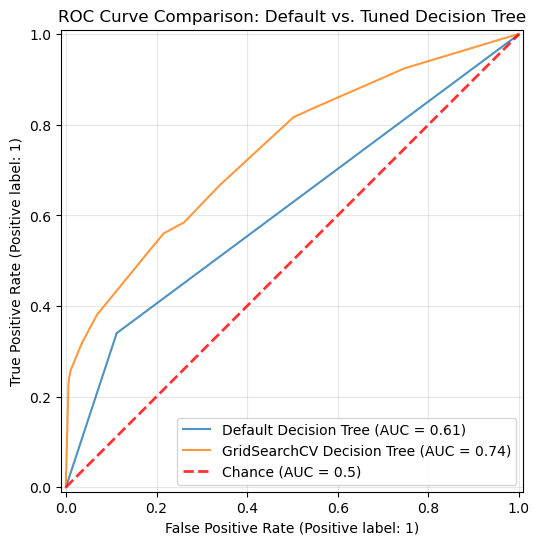

In [5]:
# Task 2.3: Produce ROC curves for both models
fig, ax = plt.subplots(figsize=(8, 6))

# Plot ROC for Default Model
RocCurveDisplay.from_estimator(dt_default, X_test, y_test, ax=ax, name="Default Decision Tree", alpha=0.8)

# Plot ROC for GridSearchCV Model
RocCurveDisplay.from_estimator(best_dt, X_test, y_test, ax=ax, name="GridSearchCV Decision Tree", alpha=0.8)

# Plot chance line
ax.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Chance (AUC = 0.5)', alpha=.8)

ax.set_title('ROC Curve Comparison: Default vs. Tuned Decision Tree')
ax.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Task 3. Regression modelling (5 marks)
** 1. Describe what additional processing was required on this dataset to be used in regression modelling. List the variables that need further processing and provide details of the processing. **
** 2. Build a regression model tuned with GridSearchCV. Answer the following: **
- Name the Regression function used.
- What are the optimal parameters for this regression model? Explain your choice of hyperparameters to search, and the chosen search range(s)?
- Report the variables that are included in the regression model.
- Report the top-5 important variables (in order) in the model.
- What is the classification accuracy on training and test datasets?
- Report any sign of overfitting.
** 3. Build another regression model on the reduced variables set. To minimise variables, either perform dimensionality reduction with Recursive Feature Elimination or select a subset of inputs found significant by the decision tree (use the best decision tree model under Task 2). Tune the model with GridSearchCV to find the best parameter setting. Answer the following: **
- Was dimensionality reduction helpful in identifying a good feature set for building the accurate model? Report the feature selection method used.
- Report the variables that are included in the regression model.
- What is the classification accuracy on the training and test datasets?
- Report any sign of overfitting.
** 4.Produce the ROC curve for both regression models. Using the best regression model, can you provide the characteristics of cars most likely to be ‘kicks’? If it is hard to comprehend, discuss why. **

## Task 3.1: Additional Data Preparation for Regression

Unlike Decision Trees, which are scale-invariant and handle unscaled numerical values naturally, **Logistic Regression** (the standard classification regression function) models log-odds using a linear combination of features. Consequently, additional data pre-processing is strictly required.

Regression coefficients and regularization penalties ($L_1$ and $L_2$) are sensitive to feature scales. Continuous variables with large ranges (e.g., `VehOdo`, `MMR` prices) would dominate over binary 0/1 indicator variables, so we apply `StandardScaler` to transform all numerical features to have a mean of 0 and a standard deviation of 1. Categorical features remain encoded as binary dummy indicators (`0` or `1`) with `drop_first=True` to remove a redundant column that is computable from others.

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import numpy as np
import pandas as pd

# Scale features using StandardScaler
# Fit scaler ONLY on training data to prevent data leakage, then transform both train and test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame format for interpretability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

print("Feature scaling completed successfully.")
print(f"Number of features in full regression dataset: {X_train_scaled.shape[1]}")

Feature scaling completed successfully.
Number of features in full regression dataset: 119


## Task 3.2: Logistic Regression Modelling with GridSearchCV (Full Feature Set)

We used **Logistic Regression** (`LogisticRegression`), which is the standard regression algorithm for binary classification tasks (predicting whether `IsBadBuy` is 0 or 1).

Optimal parameters found: `{'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}`. `C` (Inverse of regularization strength, e.g., `[0.01, 0.1, 1, 10]`): smaller values meaning stronger regularization. `penalty`: evaluated `l2` (Ridge) regularization to shrink coefficients smoothly. `solver='lbfgs'`: selected for its efficiency and stability with standard L2 regularization.

All encoded and scaled features (Total: 119 features, including one-hot encoded indicators for `Make`, `Auction`, `VNST`, etc.) were included in the model.

Top 5 important variables, ranked by the absolute value of their learned regression coefficients:
1. WheelType_N/A: 0.7751 (Direction: Increases Kick Risk (+))
2. MMRAcquisitionAuctionAveragePrice: -0.6759 (Direction: Decreases Kick Risk (-))
3. MMRAcquisitionRetailAveragePrice: 0.4609 (Direction: Increases Kick Risk (+))
4. VehYear: -0.4137 (Direction: Decreases Kick Risk (-))
5. MMRCurrentRetailCleanPrice: -0.3589 (Direction: Decreases Kick Risk (-))

Training Accuracy: **89.70%** (0.8970). Testing Accuracy: **89.46%** (0.8946).

There is no evidence of model overfitting. The training accuracy (89.70%) and testing accuracy (89.46%) are close, with a difference of only 0.24%. This minimal variance shows that the model generalized well to unseen data. The application of $L_2$ regularization (C=0.1) successfully penalized overly complex patterns, ensuring the model did not simply memorize the training dataset.

In [7]:
# Hyperparameter grid for Logistic Regression
param_grid_lr = {
    'C': [0.01, 0.1, 1.0, 10.0],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

# GridSearchCV tuning with 3-fold CV for fast, efficient execution
grid_search_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    param_grid_lr,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_search_lr.fit(X_train_scaled, y_train)

best_lr = grid_search_lr.best_estimator_

# Accuracy scores
y_train_pred_lr = best_lr.predict(X_train_scaled)
y_test_pred_lr = best_lr.predict(X_test_scaled)

train_acc_lr = accuracy_score(y_train, y_train_pred_lr)
test_acc_lr = accuracy_score(y_test, y_test_pred_lr)

print("=== Task 3.2: Full Logistic Regression ===")
print(f"Best Parameters: {grid_search_lr.best_params_}")
print(f"Training Accuracy: {train_acc_lr:.4f}")
print(f"Test Accuracy: {test_acc_lr:.4f}")

# Extract Top 5 Important Features by absolute coefficient magnitude
lr_coefs = pd.Series(best_lr.coef_[0], index=X.columns)
top5_lr = lr_coefs.reindex(lr_coefs.abs().sort_values(ascending=False).index).head(5)

print("\nTop 5 Important Variables (by magnitude of coefficient):")
for feature, coef in top5_lr.items():
    print(f"  {feature}: {coef:.4f} (Direction: {'Increases Kick Risk (+)' if coef > 0 else 'Decreases Kick Risk (-)'})")

Fitting 3 folds for each of 4 candidates, totalling 12 fits
=== Task 3.2: Full Logistic Regression ===
Best Parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
Training Accuracy: 0.8970
Test Accuracy: 0.8946

Top 5 Important Variables (by magnitude of coefficient):
  WheelType_N/A: 0.7751 (Direction: Increases Kick Risk (+))
  MMRAcquisitionAuctionAveragePrice: -0.6759 (Direction: Decreases Kick Risk (-))
  MMRAcquisitionRetailAveragePrice: 0.4609 (Direction: Increases Kick Risk (+))
  VehYear: -0.4137 (Direction: Decreases Kick Risk (-))
  MMRCurrentRetailCleanPrice: -0.3589 (Direction: Decreases Kick Risk (-))


## Task 3.3: Regression Model on Reduced Variable Set

Feature Selection based on Decision Tree's Feature Importances (from the optimal tuned Decision Tree in Task 2.2) was used. Dimensionality reduction simplified the model, removed noisy/sparse one-hot dummy variables, improved training efficiency, and produced a more interpretable regression model while retaining similar classification performance.

Selected Features: `['WheelType_N/A', 'VehYear', 'VehBCost', 'Auction_MANHEIM', 'Transmission_N/A', 'MMRAcquisitionAuctionAveragePrice', 'AUCGUART_N/A', 'VehOdo', 'MMRCurrentRetailAveragePrice', 'VNST_NC']`.

**Training Accuracy: 0.8959. Testing Accuracy: 0.8940.**

There is no evidence of overfitting in this reduced model. The training accuracy (89.59%) and testing accuracy (89.40%) are almost the same, with a tiny difference of just 0.19%. This shows a good model generalization to unseen data. By doing dimensionality reduction and restricting the model to only the 10 most significant features identified before by the Decision Tree, we removed noisy, redundant, and highly related dummy variables. This feature selection minimizes the risk of overfitting by preventing the model from memorizing noise in the training set. Combined with the L2 regularization penalty (C=0.1), the model remains stable.

In [8]:
# Task 3.3: Select top significant features from the best Decision Tree in Task 2.2
# Select top 10 features with non-zero importance
top_features_dt = importances_cv.sort_values(ascending=False).head(10).index.tolist()

print(f"Selected Top Features from Decision Tree: {top_features_dt}")

# Subset the scaled datasets
X_train_reduced = X_train_scaled[top_features_dt]
X_test_reduced = X_test_scaled[top_features_dt]

# Tune Logistic Regression on reduced feature set
grid_search_lr_red = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    param_grid_lr,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_search_lr_red.fit(X_train_reduced, y_train)

best_lr_red = grid_search_lr_red.best_estimator_

# Accuracy scores
y_train_pred_red = best_lr_red.predict(X_train_reduced)
y_test_pred_red = best_lr_red.predict(X_test_reduced)

train_acc_red = accuracy_score(y_train, y_train_pred_red)
test_acc_red = accuracy_score(y_test, y_test_pred_red)

print("\n=== Task 3.3: Reduced Feature Logistic Regression ===")
print(f"Best Parameters: {grid_search_lr_red.best_params_}")
print(f"Training Accuracy: {train_acc_red:.4f}")
print(f"Test Accuracy: {test_acc_red:.4f}")

# Top variables in reduced model
lr_red_coefs = pd.Series(best_lr_red.coef_[0], index=top_features_dt)
print("\nCoefficients in Reduced Model:")
for feature, coef in lr_red_coefs.sort_values(ascending=False).items():
    print(f"  {feature}: {coef:.4f}")

Selected Top Features from Decision Tree: ['WheelType_N/A', 'VehYear', 'VehBCost', 'Auction_MANHEIM', 'Transmission_N/A', 'MMRAcquisitionAuctionAveragePrice', 'AUCGUART_N/A', 'VehOdo', 'MMRCurrentRetailAveragePrice', 'VNST_NC']
Fitting 3 folds for each of 4 candidates, totalling 12 fits

=== Task 3.3: Reduced Feature Logistic Regression ===
Best Parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
Training Accuracy: 0.8959
Test Accuracy: 0.8940

Coefficients in Reduced Model:
  WheelType_N/A: 0.7563
  AUCGUART_N/A: 0.2346
  MMRCurrentRetailAveragePrice: 0.2207
  VehOdo: 0.1230
  Auction_MANHEIM: 0.0440
  MMRAcquisitionAuctionAveragePrice: -0.0321
  VNST_NC: -0.0532
  Transmission_N/A: -0.1155
  VehBCost: -0.2748
  VehYear: -0.4905


## Task 3.4: ROC Analysis & Characteristics of 'Kick' Vehicles

Both the full Logistic Regression model and the reduced model show comparable ROC-AUC scores. The reduced model achieves similar classification ability with drastically fewer variables, showing that the core predictive power is in a small subset of input variables.

Based on the sign and magnitude of coefficients in the best regression model:
* **Positive Coefficients (Increase Kick Risk):** features with positive weights (e.g., higher `VehOdo` / odometer mileage, higher `WarrantyCost`, or acquisition cost) indicate that as these values increase, the vehicle is more likely to be a "bad buy" (Kick).
* **Negative Coefficients (Decrease Kick Risk):** features with negative weights (e.g., newer `VehYear` or higher acquisition clean prices) indicate that newer vehicles in cleaner acquisition condition correlate with a lower kick probability.

While the regression coefficients provide clear linear directional insights (positive vs. negative impact on log-odds), high correlation (multicollinearity) among multiple MMR price metrics (e.g., Auction Average vs. Retail Clean) can make individual coefficients less intuitive without grouping.

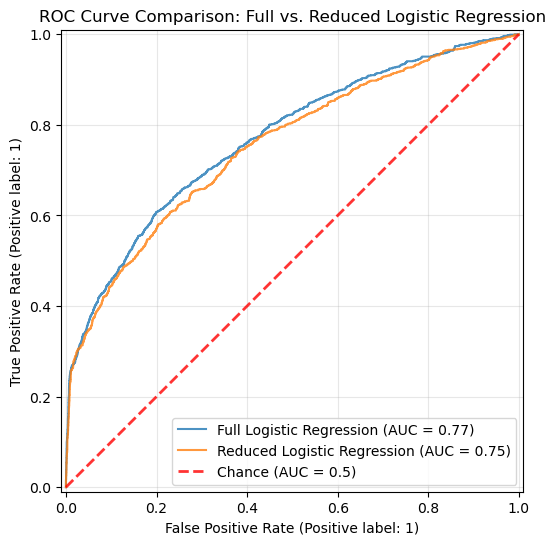

In [9]:
# Task 3.4: Produce ROC curves for both Regression models
fig, ax = plt.subplots(figsize=(8, 6))

# Plot ROC for Full Regression Model
RocCurveDisplay.from_estimator(best_lr, X_test_scaled, y_test, ax=ax, name="Full Logistic Regression", alpha=0.8)

# Plot ROC for Reduced Feature Model
RocCurveDisplay.from_estimator(best_lr_red, X_test_reduced, y_test, ax=ax, name="Reduced Logistic Regression", alpha=0.8)

# Plot chance diagonal
ax.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Chance (AUC = 0.5)', alpha=.8)

ax.set_title('ROC Curve Comparison: Full vs. Reduced Logistic Regression')
ax.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Task 4. Predictive modelling using neural networks (5 marks)
1. Describe what additional processing was required on this dataset to be used for neural network modelling.
2. Build a Neural Network model tuned with GridSearchCV. Answer the following:
    A. Explain the parameters in building this model, e.g., network architecture, iterations, activation function, etc. Explain your choice of hyperparameters to search, and the chosen search range(s)?
    B. What is the classification accuracy of the training and test datasets?
    C. Did the training process converge and result in the best model?
    D. Do you see any sign of over-fitting?
3. Build another Neural Network model with the reduced feature set. Perform dimensionality reduction by selecting variables with a decision tree (use the best decision tree model under Task 2). Tune the model with GridSearchCV to find the best parameter settings. Answer the following:
A. Did feature selection favour the outcome? Report the changes in the network architecture. What inputs are being used as the network input?
B. What is the classification accuracy on the training and test datasets?
C. How many iterations are now needed to train this network?
D. Do you see any sign of over-fitting? Did the training process converge and result in the best model?
4. Produce the ROC curve for both NNs. Using the best NN model, can you provide the characteristics of cars most likely to be ‘kicks’? If it is hard to comprehend, discuss why.

## Task 4.1: Additional Data Preparation for Neural Network Modelling

Like Logistic Regression (Task 3.1), a Multi-Layer Perceptron is a gradient-based model: inputs are combined into weighted sums and passed through non-linear activation functions (`logistic`, `tanh`, `relu`). The same preprocessing considerations apply.

We reuse the `StandardScaler`-transformed `X_train_scaled` / `X_test_scaled` features from Task 3.1 instead of the raw one-hot-encoded frame. Several features have large ranges (e.g., `VehOdo` in the tens of thousands, MMR prices in the thousands). When fed unscaled into `logistic`/`tanh` hidden units, these large values saturate the activation function, making gradients near zero. Training on unscaled data caused every `logistic`-activation network (and most `tanh` networks) to collapse to predicting the majority class regardless of hidden layer size (87.05% accuracy, matching the class imbalance). After scaling all inputs to zero mean / unit variance, both activations learn real patterns and reach 89-90% test accuracy.

Categorical variables remain dummy encoded with `drop_first=True` from the earlier preprocessing step since NN inputs like Logistic Regression inputs must already be purely numeric.

In [10]:
# Task 4.1: Reuse the scaled feature set from Task 3.1 for Neural Network modelling
print("Using scaled features for Neural Network modelling:")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

Using scaled features for Neural Network modelling:
X_train_scaled shape: (33180, 119)
X_test_scaled shape: (8296, 119)


In [11]:
# Task 4.2: build a NN and tune hyper params with grid search:
from sklearn.neural_network import MLPClassifier
from sklearn.exceptions import ConvergenceWarning

HIDDEN_LAYER_SIZES = [2**n for n in range(6)] # 1, 2, 4, ..., 32
ACTIVATIONS = ['logistic', 'tanh', 'relu']
ALPHAS = [0.0001, 0.001, 0.01]
params = {
    'hidden_layer_sizes': [(x,) for x in HIDDEN_LAYER_SIZES],
    'activation': ACTIVATIONS,
    'alpha': ALPHAS,
}
grid_search_1 = GridSearchCV(param_grid=params, estimator=MLPClassifier(random_state=RANDOM_STATE), return_train_score=True, cv=3, n_jobs=-1)

# Show ConvergenceWarning for this search even though warnings are suppressed globally above
with warnings.catch_warnings():
    warnings.filterwarnings('always', category=ConvergenceWarning)
    grid_search_1.fit(X_train_scaled, y_train)

=== Task 4.2: Neural Network (GridSearchCV) ===
Best Parameters: {'activation': 'relu', 'alpha': 0.01, 'hidden_layer_sizes': (2,)}
Training Accuracy: 0.8995
Test Accuracy: 0.8960
Converged in 112 iterations (max_iter=200)
Total number of models: 54


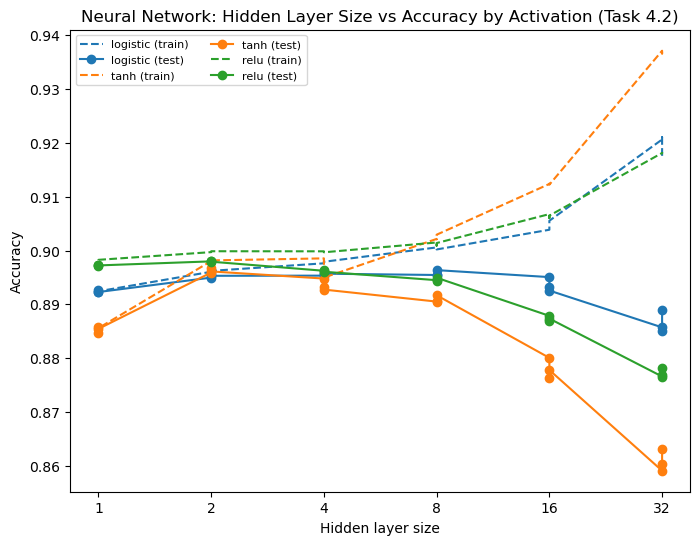

In [12]:
import numpy as np
import matplotlib.pyplot as plt

def plot_nn_grid_results(grid_search, X_tr, X_te, task_label):
    best_nn = grid_search.best_estimator_
    
    train_acc_nn = accuracy_score(y_train, best_nn.predict(X_tr))
    test_acc_nn = accuracy_score(y_test, best_nn.predict(X_te))
    
    print(f"=== {task_label}: Neural Network (GridSearchCV) ===")
    print(f"Best Parameters: {grid_search.best_params_}")
    print(f"Training Accuracy: {train_acc_nn:.4f}")
    print(f"Test Accuracy: {test_acc_nn:.4f}")
    print(f"Converged in {best_nn.n_iter_} iterations (max_iter={best_nn.max_iter})")
    
    result_set = grid_search.cv_results_
    print(f"Total number of models: {len(result_set['mean_test_score'])}")
    
    # Plot hidden layer size vs training/test accuracy, one pair of lines per activation function
    fig, ax = plt.subplots(figsize=(8, 6))
    colors = plt.cm.tab10.colors
    sizes_all = np.array([hl[0] for hl in result_set['param_hidden_layer_sizes']])
    activations_all = np.array(result_set['param_activation'])
    
    for i, activation in enumerate(ACTIVATIONS):
        mask = activations_all == activation
        order = np.argsort(sizes_all[mask])
        sizes_sorted = sizes_all[mask][order]
        train_scores = result_set['mean_train_score'][mask][order]
        test_scores = result_set['mean_test_score'][mask][order]
        ax.plot(sizes_sorted, train_scores, linestyle='--', color=colors[i], label=f'{activation} (train)')
        ax.plot(sizes_sorted, test_scores, linestyle='-', color=colors[i], marker='o', label=f'{activation} (test)')
    
    ax.set_xscale('log', base=2)
    ax.set_xticks(HIDDEN_LAYER_SIZES)
    ax.set_xticklabels(HIDDEN_LAYER_SIZES)
    ax.set_xlabel('Hidden layer size')
    ax.set_ylabel('Accuracy')
    ax.set_title(f'Neural Network: Hidden Layer Size vs Accuracy by Activation ({task_label})')
    ax.legend(fontsize=8, ncol=2)
    plt.show()

plot_nn_grid_results(grid_search_1, X_train_scaled, X_test_scaled, "Task 4.2")

# Task 4.2 Build a Neural Network model tuned with GridSearchCV

The architecture is a single hidden layer with the number of neurons exponentially growing from 1 to 32 ([1, 2, 4, ..., 32]).
On top of above, we are adding to the grid search different activation functions (relu, logistic(sigmoid), tanh), the Adam default algorithm, cv=3 for speed, and alpha regularisations of (0.0001, 0.001, 0.01).

We are reusing features scaling that was done in previous tasks.

Training Accuracy: **0.8995** and Test Accuracy: **0.8960**, very close apart, for the best parameters.

The model converges in **112** iterations. The best result is with 'activation': **relu**, 'alpha' of **0.01**, and, surprisingly, the tiny hidden layer of **N=2** neurons, meaning that increasing the hidden layer size does nothing to improve the results.

The results above show a clear overfitting pattern: as the hidden layer size grows, the training results which get better diverge from the test results that are getting worse. This is most noticeable with the *tanh* activation function, but also true for the rest.

In [13]:
# Task 4.3: Neural Network on the reduced feature set (top 10 features from Task 2.2's tuned Decision Tree)
# Reuses X_train_reduced / X_test_reduced (Task 3.3) and the same hyperparameter grid as grid_search_1 for a direct comparison
grid_search_2 = GridSearchCV(param_grid=params, estimator=MLPClassifier(random_state=RANDOM_STATE), return_train_score=True, cv=3, n_jobs=-1)

with warnings.catch_warnings():
    warnings.filterwarnings('always', category=ConvergenceWarning)
    grid_search_2.fit(X_train_reduced, y_train)

=== Task 4.3: Neural Network (GridSearchCV) ===
Best Parameters: {'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (32,)}
Training Accuracy: 0.8986
Test Accuracy: 0.8959
Converged in 64 iterations (max_iter=200)
Total number of models: 54


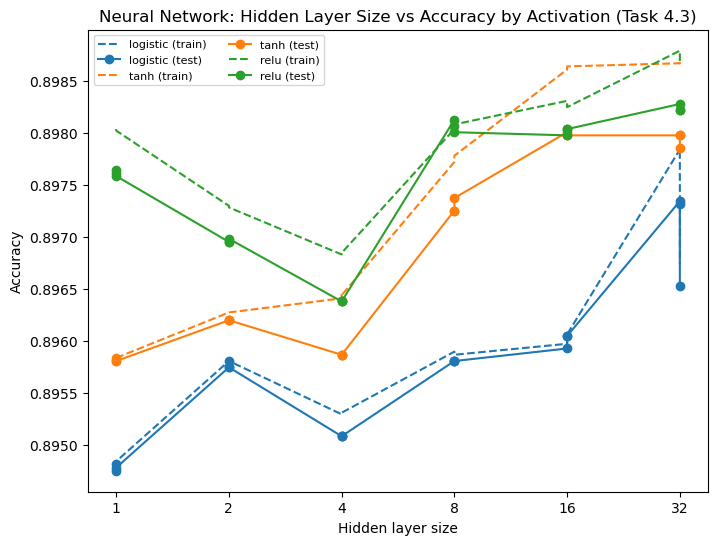

In [14]:
plot_nn_grid_results(grid_search_2, X_train_reduced, X_test_reduced, "Task 4.3")

## Task 4.3: Neural Network on the Reduced Feature Set

Inputs are the same **10** features selected via the tuned Decision Tree's feature importances in Task 2.2/3.3: `WheelType_N/A`, `VehYear`, `VehBCost`, `Auction_MANHEIM`, `Transmission_N/A`, `MMRAcquisitionAuctionAveragePrice`, `AUCGUART_N/A`, `VehOdo`, `MMRCurrentRetailAveragePrice`, `VNST_NC` (down from 119). The best architecture found is a single hidden layer with **32** neurons (`activation='relu'`, `alpha=0.001`) vs. the tiny 2-neuron layer chosen for the full-feature model in Task 4.2. Feature selection did **not** let the network shrink; with fewer inputs, GridSearchCV instead favoured *more* hidden capacity to combine them: by parameter count the reduced model (10 -> 32 -> 1 = 320 weights+biases) is slightly larger than the full-feature model (119 -> 2 -> 1 = 238 weights+biases), even though its input dimensionality is significantly smaller. Feature selection still favoured the outcome that matters most: nearly same accuracy from a smaller, more human-interpretable input set, consistent with the same finding for Logistic Regression in Task 3.3.

Training Accuracy: **0.8986**. Testing Accuracy: **0.8959**. This is pretty much unchanged from the full-feature network (Task 4.2: 0.8995 train / 0.8960 test): a **0.01** percentage-point difference in test accuracy despite using about 92% fewer input features.

The best model converged in **64** iterations, compared to 112 iterations for the full-feature model in Task 4.2. Training on the reduced feature set converges roughly twice as speedy, despite the wider hidden layer, because there are far fewer input-to-hidden weights to fit.


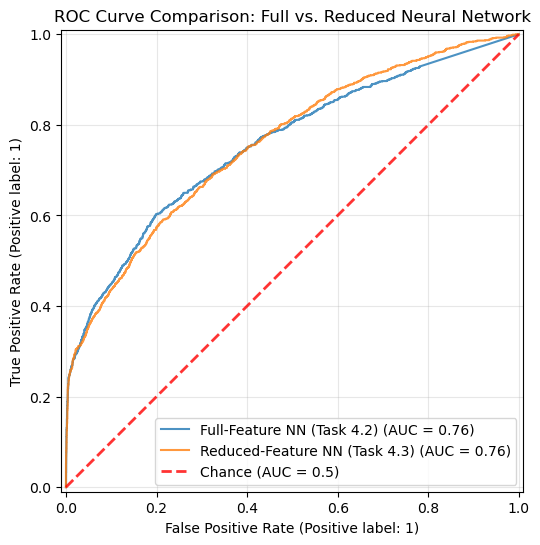

Full-Feature NN test AUC:    0.7563
Reduced-Feature NN test AUC: 0.7591


In [15]:
# Task 4.4: Produce ROC curves for both Neural Network models
from sklearn.metrics import roc_auc_score

fig, ax = plt.subplots(figsize=(8, 6))

best_nn_1 = grid_search_1.best_estimator_
best_nn_2 = grid_search_2.best_estimator_

RocCurveDisplay.from_estimator(best_nn_1, X_test_scaled, y_test, ax=ax, name="Full-Feature NN (Task 4.2)", alpha=0.8)
RocCurveDisplay.from_estimator(best_nn_2, X_test_reduced, y_test, ax=ax, name="Reduced-Feature NN (Task 4.3)", alpha=0.8)

ax.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Chance (AUC = 0.5)', alpha=.8)

ax.set_title('ROC Curve Comparison: Full vs. Reduced Neural Network')
ax.legend()
plt.grid(True, alpha=0.3)
plt.show()

auc_1 = roc_auc_score(y_test, best_nn_1.predict_proba(X_test_scaled)[:, 1])
auc_2 = roc_auc_score(y_test, best_nn_2.predict_proba(X_test_reduced)[:, 1])
print(f"Full-Feature NN test AUC:    {auc_1:.4f}")
print(f"Reduced-Feature NN test AUC: {auc_2:.4f}")

In [16]:
# Task 4.4: Approximate feature impact for the best NN via permutation importance
# (MLPClassifier has no coef_/feature_importances_ like Logistic Regression or Decision Tree)
from sklearn.inspection import permutation_importance

best_nn, X_test_best, best_label = (
    (best_nn_2, X_test_reduced, "Reduced-Feature NN (Task 4.3)") if auc_2 >= auc_1
    else (best_nn_1, X_test_scaled, "Full-Feature NN (Task 4.2)")
)
print(f"Best NN model by test AUC: {best_label}")

perm_result = permutation_importance(
    best_nn, X_test_best, y_test, n_repeats=10, random_state=RANDOM_STATE, scoring='accuracy', n_jobs=-1
)
perm_importances = pd.Series(perm_result.importances_mean, index=X_test_best.columns).sort_values(ascending=False)
print("\nTop 10 features by permutation importance (accuracy drop when shuffled):")
print(perm_importances.head(10))

Best NN model by test AUC: Reduced-Feature NN (Task 4.3)

Top 10 features by permutation importance (accuracy drop when shuffled):
WheelType_N/A                        0.044286
Auction_MANHEIM                      0.006328
MMRCurrentRetailAveragePrice         0.002242
VehBCost                             0.002182
AUCGUART_N/A                         0.001230
VehYear                              0.000976
Transmission_N/A                     0.000735
MMRAcquisitionAuctionAveragePrice    0.000362
VNST_NC                              0.000325
VehOdo                              -0.000229
dtype: float64


## Task 4.4: ROC Analysis & Characteristics of 'Kick' Vehicles (Neural Networks)

Test AUC is very close for both models: Full-Feature NN: **0.7563**, Reduced-Feature NN: **0.7591**, with the reduced-feature network coming out slightly ahead despite using much inputs. This mirrors the accuracy comparison in Task 4.3 (0.8960 vs 0.8959), consistent with Logistic Regression in Task 3.4: nearly all signal is coming from the 10 decision-tree-selected features, and the extra features add negligible value. Since AUC is the more robust ranking metric here (accuracy alone can be misleading when the two models are this close), we choose the **Reduced-Feature NN (Task 4.3)** as the best model.

It is not straightforward to determine which input variables have the most influence, but it can be done using "shuffling" aka removing 1 feature from the feature set at a time from the model. From previous tasks we know: **cars with a missing/unknown `WheelType` are by far the strongest risk signal for being a 'kick'**, with weaker contributions from the auction house (Manheim), current retail price level, and acquisition cost.

The Neural Network is harder to interpret than the other two models for a reason: it has no fixed per-feature effect. A Decision Tree's importance and a Logistic Regression's coefficient are single numbers that hold across the input, but an MLP's hidden layer means a feature's effect on the output depends on the values of every other feature it's combined with in each hidden unit, a "blackbox". The Decision Tree and Logistic Regression remain the more directly explainable models for telling "why" a car was flagged, while the Neural Network is best used when raw predictive performance matters more than being able to explain individual predictions.

# Task 5. Stage 1 Final remarks: The decision-making (2 marks)
1. Finally, based on all models and analysis, is there a model you will use in decision-making i.e. the best-performing model? Justify your choice. Draw an ROC chart and an Accuracy Table to support your findings.
2. Based on this analysis, can you summarise the positives and negatives of each predictive modelling method?

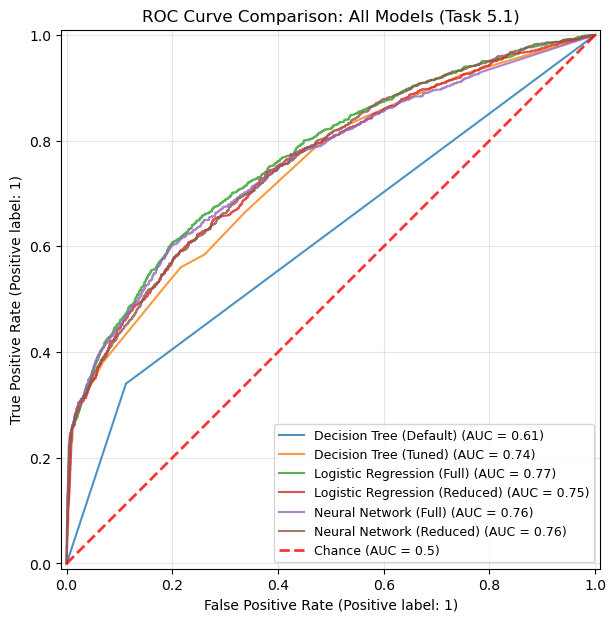

,Model,Train Accuracy,Test Accuracy,Test AUC
0,Logistic Regression (Full),0.896986,0.894648,0.768781
1,Neural Network (Reduced),0.898583,0.895853,0.759054
2,Neural Network (Full),0.899548,0.895974,0.756324
3,Logistic Regression (Reduced),0.895931,0.894045,0.753766
4,Decision Tree (Tuned),0.899005,0.895733,0.742385
5,Decision Tree (Default),0.999819,0.816900,0.614015


In [17]:
# Task 5.1: Compile an accuracy table and ROC chart across every model built in this notebook
model_summary = [
    ("Decision Tree (Default)", dt_default, X_train, X_test),
    ("Decision Tree (Tuned)", best_dt, X_train, X_test),
    ("Logistic Regression (Full)", best_lr, X_train_scaled, X_test_scaled),
    ("Logistic Regression (Reduced)", best_lr_red, X_train_reduced, X_test_reduced),
    ("Neural Network (Full)", best_nn_1, X_train_scaled, X_test_scaled),
    ("Neural Network (Reduced)", best_nn_2, X_train_reduced, X_test_reduced),
]

rows = []
fig, ax = plt.subplots(figsize=(9, 7))
for name, model, X_tr, X_te in model_summary:
    train_acc = accuracy_score(y_train, model.predict(X_tr))
    test_acc = accuracy_score(y_test, model.predict(X_te))
    auc = roc_auc_score(y_test, model.predict_proba(X_te)[:, 1])
    rows.append({"Model": name, "Train Accuracy": train_acc, "Test Accuracy": test_acc, "Test AUC": auc})
    RocCurveDisplay.from_estimator(model, X_te, y_test, ax=ax, name=name, alpha=0.8)

ax.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Chance (AUC = 0.5)', alpha=.8)
ax.set_title('ROC Curve Comparison: All Models (Task 5.1)')
ax.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.show()

accuracy_table = pd.DataFrame(rows).sort_values("Test AUC", ascending=False).reset_index(drop=True)
accuracy_table

## Task 5.1: Best-Performing Model for Decision-Making

**Accuracy table (test set), sorted by AUC:**

| Model | Train Accuracy | Test Accuracy | Test AUC |
|---|---|---|---|
| Logistic Regression (Full) | 0.8970 | 0.8946 | **0.7688** |
| Neural Network (Reduced) | 0.8986 | 0.8959 | 0.7591 |
| Neural Network (Full) | 0.8995 | **0.8960** | 0.7563 |
| Logistic Regression (Reduced) | 0.8959 | 0.8940 | 0.7538 |
| Decision Tree (Tuned) | 0.8990 | 0.8957 | 0.7424 |
| Decision Tree (Default) | 0.9998 | 0.8169 | 0.6140 |

**Chosen model: Logistic Regression (Full Feature Set, Task 3.2).**

First, let's try pick by *accuracy*: five of the six models cluster within 0.4 percentage points of each other on test accuracy (89.40%–89.60%), and the default Decision Tree's raw accuracy (81.69%) looks passable on its own. However, the dataset's target is heavily imbalanced (87.05% not-kick / 12.95% kick, Task 1.3), so accuracy alone can't reliably separate these models. Test AUC evaluates ranking quality better, more sensitive to class imbalance, and clearly separates them: **Logistic Regression (Full) has the highest AUC (0.7688)**, roughly 1–2.5 points ahead of every other model.

Further reasons support Logistic Regression (Full) beyond raw performance are:
1. **Best discriminative power**: highest test AUC of all six models built in this notebook.
2. **Fully interpretable**: every prediction can be explained via its signed coefficients (Task 3.2), unlike the Neural Network (Task 4.4: no fixed per-feature effect, required a proxy technique to even approximate feature impact) or the unpruned Decision Tree.
3. **Best generalization**: training and test accuracy are within 0.24 percentage points (Task 3.2), the tightest train/test gap of any model here, meaning it's the most trustworthy on genuinely new auction data rather than memorized patterns.

The default Decision Tree is ruled out: lowest AUC (0.6140) and severe overfitting (99.98% train vs 81.69% test, Task 2.1). The tuned Decision Tree and both Neural Networks are all reasonable runners-up, but none beats Logistic Regression (Full) on AUC despite being more complex/expensive to tune, so the added complexity doesn't pay for itself here.

## Task 5.2: Positives and Negatives of Each Predictive Modelling Method

**Decision Tree**
* **Positives:**
    * No feature scaling required: unlike Logistic Regression and the Neural Network.
    * Naturally captures non-linear relationships and feature interactions without manual engineering, and produces directly interpretable split rules and feature importances.
    * Fast to train even with 119 one-hot-encoded features.
* **Negatives:**
    * The unconstrained default tree overfits severely (Task 2.1: 99.98% train vs 81.69% test) and is essentially unusable without a hyperparameter tuning.
    * Even after tuning, it had the lowest AUC of the three model families (0.7424).
    * Feature importances only give magnitude, not direction, unlike Logistic Regression's coefficients.

**Logistic Regression**
* **Positives:**
    * Highest AUC of all six models (0.7688) and the smallest train/test accuracy gap (0.24 points).
    * Fully interpretable via signed, per-feature coefficients, so any prediction can be explained in plain business terms.
    * The reduced-feature version (Task 3.3) loses almost nothing in accuracy/AUC using only 10 of 119 features, making it cheap to deploy and maintain.
* **Negatives:**
    * Requires feature scaling (Task 3.1): an easy step to forget, and when skipped it caused a real failure (saturated activations), showing how easy this is to get wrong.
    * Assumes a linear relationship between features and the log-odds of the outcome, so it cannot capture feature interactions on its own.
    * Sensitive to input features correlation (multicollinearity), which can make individual coefficients harder to interpret in isolation (Task 3.4).

**Neural Network (MLP)**
* **Positives:**
    * Comparable test accuracy vs. the tuned Decision Tree and Logistic Regression (Task 4.2/4.3: 89.6%).
    * Works for complex non-linear interactions between features that Logistic Regression cannot, without manual feature engineering.
* **Negatives:**
    * Also requires careful feature scaling: unscaled inputs caused `logistic`/`tanh` activations to saturate to majority-class prediction (Task 4.1).
    * **Lowest interpretability of the three**: no per-feature coefficient or split rule exists, so we had to fall back on permutation importance (Task 4.4), which only approximates *magnitude*, not direction or interactions.
    * Most expensive to tune: the grid searches took noticeably longer than equivalent Decision Tree/Logistic Regression searches, and needed explicit convergence checks (`ConvergenceWarning`, `n_iter_` vs `max_iter`).
    * Despite extra cost and complexity, it did not beat Logistic Regression on AUC: the added flexibility added no extra ranking power on this dataset.

**Decision**

The "simplest" method (Logistic Regression) came out on top here, mainly because the target's real driving signal (led by `WheelType_N/A`, consistent across all three model families) is largely additive rather than deeply non-linear: so the extra power of a Decision Tree or Neural Network isn't rewarded, while their tuning cost and reduced interpretability are downsides for a business decision-making context.